In [16]:
# Paso 1: Cargar los datos
    #En este paso deberá cargar el **archivo CSV** llamado "Caso 1 .csv"que contiene la información del problema.
        #1. Ejecute la siguiente celda de código.
        #2. Aparecerá un botón que le permitirá **seleccionar el archivo desde su computador**.
        #3. Una vez cargado el archivo, el notebook mostrará **las primeras filas del dataset** para verificar que los datos se hayan cargado correctamente.
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import io

print("Seleccione el archivo CSV desde su computador:")
upload = widgets.FileUpload(accept='.csv', multiple=False)
display(upload)

def load_dataset(change):
    
    # En ipywidgets v8+, change['new'] contiene la lista de archivos
    if not change['new']:
        return
    
    # Correctly access the file information when multiple=False
    # upload.value is a dictionary, so we get the first (and only) item's value
    file_info = change['new'][0]
    content = file_info['content']

    global df
    df = pd.read_csv(io.BytesIO(content), sep=';')

    print("\nDataset cargado correctamente\n")
    display(df.head())

upload.observe(load_dataset, names='value')

Seleccione el archivo CSV desde su computador:


FileUpload(value=(), accept='.csv', description='Upload')

,tiemposum,envases,distancia
0,9.95,2,50
1,24.45,8,110
2,31.75,11,120
3,35.00,10,550
4,25.02,8,295


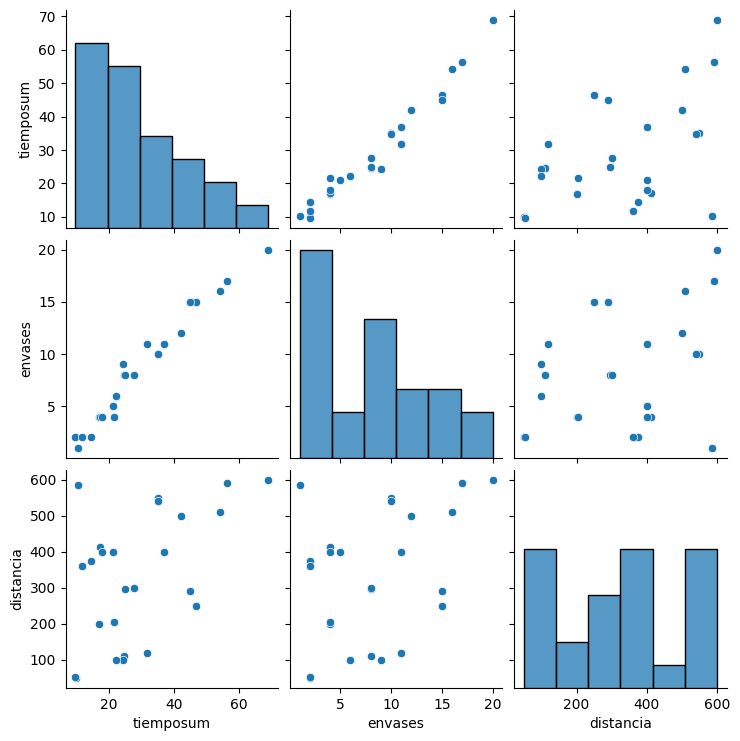

In [17]:
### Paso 2: Exploración visual de las variables
    #En este paso exploraremos las relaciones entre las variables del dataset utilizando gráficos.
    #Utilizaremos la función **pairplot** de la librería **Seaborn**, que permite visualizar:
        #1. La distribución de cada variable.
        #2. Las relaciones entre pares de variables.
        #3. Posibles patrones o correlaciones entre ellas.

#Ejecute la siguiente celda para generar las visualizaciones.

import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression

# Variables predictoras
X = df[['envases', 'distancia']]

# Variable objetivo
y = df['tiemposum']

# Crear modelo
modelo = LinearRegression()

# Entrenar modelo
modelo.fit(X, y)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [19]:
## Visualizar parametros del modelo
print("Intercepto:", modelo.intercept_)
print("Coeficientes:", modelo.coef_)

Intercepto: 2.3092004289326944
Coeficientes: [2.74036942 0.01243958]


In [20]:
from sklearn.metrics import r2_score, mean_squared_error

# Predicciones del modelo
pred = modelo.predict(X)

# Métricas de evaluación
r2 = r2_score(y, pred)
mse = mean_squared_error(y, pred)

print("Evaluación del modelo de regresión")
print("----------------------------------")
print(f"R² (coeficiente de determinación): {r2:.4f}")
print(f"MSE (error cuadrático medio): {mse:.4f}")

Evaluación del modelo de regresión
----------------------------------
R² (coeficiente de determinación): 0.9811
MSE (error cuadrático medio): 4.6019


In [21]:
from scipy.stats import shapiro



# Calcular residuos
residuos = y - pred
# prueba de normalidad
stat, p_value = shapiro(residuos)

print("Prueba de normalidad Shapiro-Wilk")
print("----------------------------------")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

Prueba de normalidad Shapiro-Wilk
----------------------------------
Estadístico: 0.9555
p-value: 0.3321


In [22]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Residuos del modelo
residuos = y - pred

# Agregar constante a X para la prueba
X_const = sm.add_constant(X)

# Prueba de Breusch-Pagan
bp_test = het_breuschpagan(residuos, X_const)

bp_labels = [
    "Lagrange multiplier statistic",
    "p-value",
    "f-value",
    "f p-value"
]

print("Prueba de Breusch-Pagan")
print("------------------------")
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value:.4f}")

Prueba de Breusch-Pagan
------------------------
Lagrange multiplier statistic: 0.6641
p-value: 0.7174
f-value: 0.3002
f p-value: 0.7437


In [23]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuos)

print("Prueba de independencia de errores")
print("----------------------------------")
print(f"Durbin-Watson: {dw:.4f}")

Prueba de independencia de errores
----------------------------------
Durbin-Watson: 2.1312


In [24]:
# Nuevos escenarios para predicción
nuevos_datos = pd.DataFrame({
    "envases": [18, 25],
    "distancia": [450, 420]
})

# Realizar predicciones
predicciones = modelo.predict(nuevos_datos)

# Mostrar resultados
resultados = nuevos_datos.copy()
resultados["tiempo_predicho"] = predicciones

print("Predicciones del tiempo de servicio:")
display(resultados)

Predicciones del tiempo de servicio:


,envases,distancia,tiempo_predicho
0,18,450,57.233662
1,25,420,76.043060
